Columns:
['Col 1', 'Col 2', 'Col 3', 'Col 4', 'Col 5', 'Col 6', 'Col 7', 'Col 8', 'Col 9', 'Col 10']

Numeric columns:
['Col 1', 'Col 2', 'Col 3', 'Col 4', 'Col 5', 'Col 6', 'Col 7', 'Col 8', 'Col 9', 'Col 10']

Analyzing: Col 1

=== TIER 1 ===
Mean: 497.5
Median: 400.5
Sample SD: 273.6068753197226
Population SD: 259.56627284761015
Standard Error: 86.52209094920337


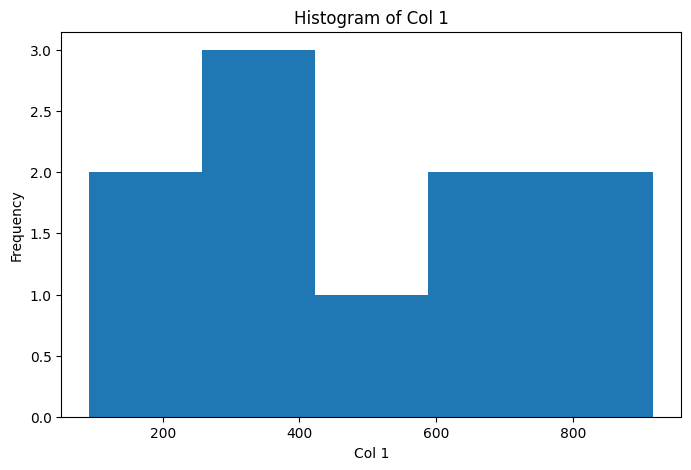


=== TIER 2 ===
Q1: 322.25
Q3: 729.25
IQR: 407.0
Skewness: 0.19912623548853958
Shapiro p-value: 0.5542732483763662
Log-transformed skewness: -0.8620673158610207
95% CI: (np.float64(301.77343221898184), np.float64(693.2265677810182))

Null Hypothesis:
Population mean = 497.5
p-value: 1.0
Not statistically significant


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load data
df = pd.read_csv("data/data.csv")

# Remove accidental spaces in column names
df.columns = df.columns.str.strip()

print("Columns:")
print(df.columns.tolist())

# Find numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if not numeric_cols:
    raise ValueError("No numeric columns found.")

print("\nNumeric columns:")
print(numeric_cols)

# Use first numeric column automatically
x_col = numeric_cols[0]
x = df[x_col].dropna()

print(f"\nAnalyzing: {x_col}")

# -------------------------
# TIER 1
# -------------------------

print("\n=== TIER 1 ===")

print("Mean:", x.mean())
print("Median:", x.median())

print("Sample SD:", x.std(ddof=1))
print("Population SD:", x.std(ddof=0))

print("Standard Error:", stats.sem(x))

# Histogram
plt.figure(figsize=(8,5))
plt.hist(x, bins="auto")
plt.title(f"Histogram of {x_col}")
plt.xlabel(x_col)
plt.ylabel("Frequency")
plt.show()

# -------------------------
# TIER 2
# -------------------------

print("\n=== TIER 2 ===")

# Quartiles
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)
iqr = q3 - q1

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)

# Skewness
skew = stats.skew(x)
print("Skewness:", skew)

# Normality
if len(x) >= 3:
    shapiro = stats.shapiro(x)
    print("Shapiro p-value:", shapiro.pvalue)

# Log transform if positive
if (x > 0).all():
    log_x = np.log(x)
    print("Log-transformed skewness:",
          stats.skew(log_x))

# Confidence Interval
ci = stats.t.interval(
    0.95,
    len(x)-1,
    loc=x.mean(),
    scale=stats.sem(x)
)

print("95% CI:", ci)

# One-sample t-test
# Compare against a meaningful null hypothesis value instead of the sample mean.
hypothesized_mean = 0  # adjust as appropriate for your dataset/domain
ttest = stats.ttest_1samp(x, hypothesized_mean)

print("\nNull Hypothesis:")
print("Population mean =", round(hypothesized_mean, 3))

print("p-value:", ttest.pvalue)

alpha = 0.05

if ttest.pvalue < alpha:
    print("Statistically significant")
else:
    print("Not statistically significant")

# -------------------------
# Frequency tables for categorical columns
# -------------------------

cat_cols = df.select_dtypes(
    exclude=np.number
).columns.tolist()

for col in cat_cols:
    print(f"\n=== {col} ===")

    freq = df[col].value_counts()
    print("Frequency:")
    print(freq)

    print("\nProportion (%):")
    print((freq / len(df) * 100).round(2))

    freq.plot(kind="bar")
    plt.title(col)
    plt.show()

# -------------------------
# ANOVA
# -------------------------

if cat_cols:

    group_col = cat_cols[0]

    groups = []

    for _, g in df.groupby(group_col):
        vals = g[x_col].dropna()

        if len(vals) > 1:
            groups.append(vals)

    if len(groups) >= 2:

        anova = stats.f_oneway(*groups)

        print("\n=== ANOVA ===")
        print("F:", anova.statistic)
        print("p-value:", anova.pvalue)

# -------------------------
# Chi-Square
# -------------------------

if len(cat_cols) >= 2:

    table = pd.crosstab(
        df[cat_cols[0]],
        df[cat_cols[1]]
    )

    chi2, p, dof, expected = stats.chi2_contingency(table)

    print("\n=== Chi-Square ===")
    print("Chi-square:", chi2)
    print("p-value:", p)
    print("Degrees of freedom:", dof)